# Phase 5: Model Evaluation

**Goal:** Deep evaluation using bank-standard metrics — ROC-AUC, KS statistic, Gini coefficient, and Precision-Recall. Understand the cost-based threshold decision.

In [1]:
import sys
sys.path.append('..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from src.data.loader import load_raw
from src.features.engineer import engineer, split
from src.models.evaluate import report, ks_statistic

sns.set_theme(style='whitegrid', palette='muted')

In [2]:
with open('../models/xgboost.pkl', 'rb') as f:
    model = pickle.load(f)

df = engineer(load_raw())
X_train, X_test, y_train, y_test = split(df)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = report(y_test, y_prob)
print(f"ROC-AUC : {metrics['roc_auc']}")
print(f"KS      : {metrics['ks']}")
print(f"Gini    : {metrics['gini']}")

ROC-AUC : 0.8641
KS      : 0.5776
Gini    : 0.7282


## 1. ROC Curve

AUC = probability that the model ranks a random defaulter higher than a random non-defaulter. A random classifier scores 0.5.

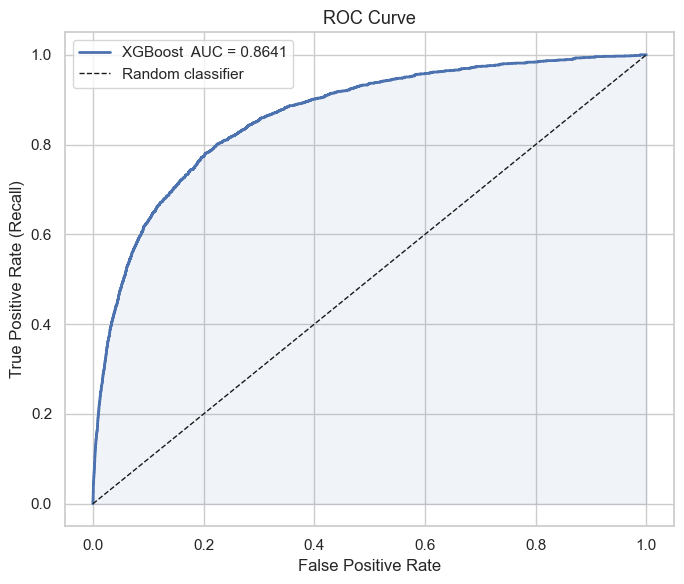

In [3]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#4C72B0', lw=2,
        label=f'XGBoost  AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 2. KS Plot

The KS statistic is the maximum vertical distance between the cumulative TPR and FPR curves. It is the primary discriminatory metric in credit scoring — banks typically target KS > 0.30.

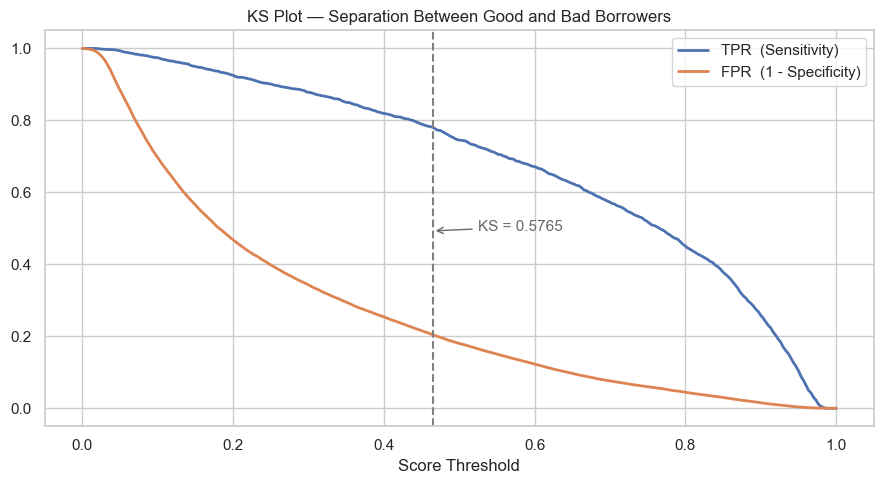

In [4]:
thresholds = np.linspace(0, 1, 300)
tprs, fprs = [], []

for t in thresholds:
    pred = (y_prob >= t).astype(int)
    tp = ((pred == 1) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    tn = ((pred == 0) & (y_test == 0)).sum()
    tprs.append(tp / (tp + fn + 1e-10))
    fprs.append(fp / (fp + tn + 1e-10))

tprs, fprs = np.array(tprs), np.array(fprs)
ks_idx = np.argmax(tprs - fprs)
ks_val = tprs[ks_idx] - fprs[ks_idx]
ks_thresh = thresholds[ks_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, tprs, label='TPR  (Sensitivity)', color='#4C72B0', lw=2)
ax.plot(thresholds, fprs, label='FPR  (1 - Specificity)', color='#DD8452', lw=2)
ax.axvline(ks_thresh, color='gray', linestyle='--')
mid = (tprs[ks_idx] + fprs[ks_idx]) / 2
ax.annotate(f'KS = {ks_val:.4f}',
            xy=(ks_thresh, mid),
            xytext=(ks_thresh + 0.06, mid),
            fontsize=11, color='dimgray',
            arrowprops=dict(arrowstyle='->', color='dimgray'))
ax.set_xlabel('Score Threshold')
ax.set_title('KS Plot — Separation Between Good and Bad Borrowers', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Precision-Recall Curve

In credit, **missing a defaulter (low recall) is more costly** than a false alarm (low precision). This curve lets you choose a threshold that reflects that business priority.

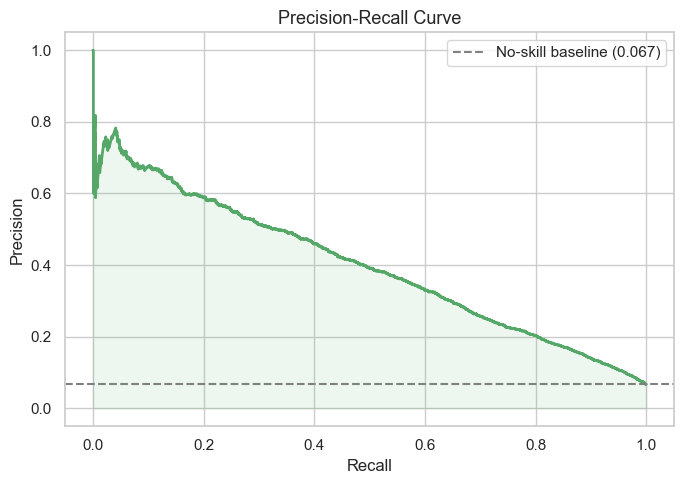

In [5]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, color='#55A868', lw=2)
ax.fill_between(recall, precision, alpha=0.1, color='#55A868')
ax.axhline(y_test.mean(), color='gray', linestyle='--',
           label=f'No-skill baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Threshold Selection & Confusion Matrix

Default threshold of 0.5 is wrong for imbalanced problems. We choose 0.15 to catch more defaulters at the cost of more false alarms — appropriate when loan defaults are expensive.

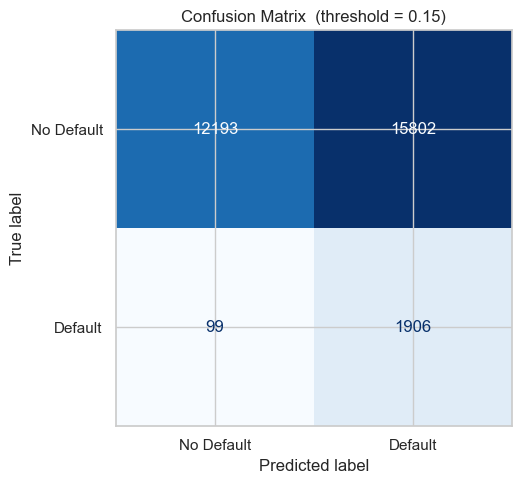

Precision : 0.1076
Recall    : 0.9506
False alarms caught per true default flagged: 8.3


In [6]:
THRESHOLD = 0.15
y_pred = (y_prob >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix  (threshold = {THRESHOLD})', fontsize=12)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Precision : {tp / (tp + fp):.4f}")
print(f"Recall    : {tp / (tp + fn):.4f}")
print(f"False alarms caught per true default flagged: {fp / tp:.1f}")